# Notebook 01 — Graph Construction & Bottleneck Audit
**Run after 00_eda.ipynb**

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
print('Imports done')

Imports done


## 1. Load & Filter Training Data

In [2]:
# KAGGLE: df = pd.read_csv('/kaggle/input/delhivery-dataset/delivery_data.csv')
df = pd.read_csv('delivery_data.csv')

print(f'Total rows: {len(df):,}')
print(f'Split: {df["data"].value_counts().to_dict()}')

# CRITICAL: filter to training only
df = df[df['data'] == 'training'].copy().reset_index(drop=True)
print(f'Training rows after filter: {len(df):,}')

Total rows: 144,867
Split: {'training': 104858, 'test': 40009}
Training rows after filter: 104,858


## 2. Clean & Feature Engineer

In [3]:
for col in ['trip_creation_time','od_start_time','od_end_time','cutoff_timestamp']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df = df[(df['segment_actual_time'] > 0) & (df['segment_osrm_time'] > 0)]

df['segment_delay_ratio'] = (df['segment_actual_time'] / df['segment_osrm_time']).clip(0.1, 10)
df['is_delayed']          = df['segment_delay_ratio'] > 1.2
df['route_type_enc']      = (df['route_type'] == 'FTL').astype(int)
df['hour']                = df['trip_creation_time'].dt.hour
df['day_of_week']         = df['trip_creation_time'].dt.dayofweek

# define df_clean
df_clean = df.copy()

print(f'Clean rows: {len(df_clean):,}')
print(f'Route types: {df_clean["route_type"].unique().tolist()}')
print(f'Delayed: {df_clean["is_delayed"].mean()*100:.1f}%')
print(df_clean['segment_delay_ratio'].describe().round(3))

Clean rows: 103,049
Route types: ['Carting', 'FTL']
Delayed: 84.5%
count    103049.000
mean          2.076
std           1.446
min           0.100
25%           1.368
50%           1.692
75%           2.250
max          10.000
Name: segment_delay_ratio, dtype: float64


## 3. Build Edge Statistics

In [4]:
edge_stats = df_clean.groupby(
    ['source_center','destination_center','route_type']
).agg(
    median_delay_ratio = ('segment_delay_ratio','median'),
    sla_breach_rate    = ('is_delayed',         'mean'),
    trip_count         = ('trip_uuid',           'count'),
    median_distance    = ('segment_osrm_distance','median'),
    median_actual_time = ('segment_actual_time', 'median'),
    median_osrm_time   = ('segment_osrm_time',   'median'),
).reset_index()

print(f'Corridor-route combos: {len(edge_stats)}')

# Keep dominant route_type per corridor
edge_stats_dedup = (
    edge_stats
    .sort_values('trip_count', ascending=False)
    .drop_duplicates(subset=['source_center','destination_center'])
    .reset_index(drop=True)
)
print(f'After dedup: {len(edge_stats_dedup)} corridors')

Corridor-route combos: 2522
After dedup: 2508 corridors


## 4. Build Directed Graph

In [5]:
G = nx.DiGraph()

name_map = {
    **dict(zip(df_clean['source_center'],     df_clean['source_name'])),
    **dict(zip(df_clean['destination_center'], df_clean['destination_name']))
}
for node_id, node_name in name_map.items():
    G.add_node(node_id, name=node_name)

G.add_edges_from([
    (r['source_center'], r['destination_center'], {
        'weight':           r['median_delay_ratio'],
        'breach_rate':      r['sla_breach_rate'],
        'trip_count':       r['trip_count'],
        'route_type':       r['route_type'],
        'median_distance':  r['median_distance'],
        'actual_time':      r['median_actual_time'],
        'osrm_time':        r['median_osrm_time'],
    })
    for r in edge_stats_dedup.to_dict('records')
])

print(f'Nodes (facilities): {G.number_of_nodes()}')
print(f'Edges (corridors):  {G.number_of_edges()}')

Nodes (facilities): 1590
Edges (corridors):  2508


## 5. Compute Graph Metrics

In [6]:
print('Computing metrics... (~1-2 min)')
betweenness  = nx.betweenness_centrality(G, weight='weight', normalized=True, k=500)
in_deg       = dict(G.in_degree())
out_deg      = dict(G.out_degree())
G_undir      = G.to_undirected()
clustering   = nx.clustering(G_undir)
print('Done!')

Computing metrics... (~1-2 min)
Done!


## 6. Build Hub Metrics DataFrame

In [7]:
hub_df = pd.DataFrame({
    'hub_id':     list(G.nodes()),
    'hub_name':   [G.nodes[n].get('name',n) for n in G.nodes()],
    'betweenness':[betweenness[n] for n in G.nodes()],
    'in_degree':  [in_deg[n]      for n in G.nodes()],
    'out_degree': [out_deg[n]     for n in G.nodes()],
    'clustering': [clustering.get(n,0) for n in G.nodes()],
})

hub_df['avg_breach_rate'] = hub_df['hub_id'].apply(
    lambda node: np.mean([
        d['breach_rate']
        for _,_,d in list(G.in_edges(node,data=True)) +
                     list(G.out_edges(node,data=True))
        if 'breach_rate' in d
    ]) if G.degree(node) > 0 else 0
)

deg_norm = ((hub_df['in_degree']+hub_df['out_degree']) /
            (hub_df['in_degree']+hub_df['out_degree']).clip(lower=1).max())
hub_df['risk_score'] = (
    hub_df['betweenness']    * 0.5 +
    hub_df['avg_breach_rate']* 0.3 +
    deg_norm                 * 0.2
)
hub_df = hub_df.sort_values('risk_score',ascending=False).reset_index(drop=True)
print('Hub metrics ready!')
hub_df.head(10)

Hub metrics ready!


,hub_id,hub_name,betweenness,in_degree,out_degree,clustering,avg_breach_rate,risk_score
0,IND000000ACB,Gurgaon_Bilaspur_HB (Haryana),0.243508,41,48,0.038847,0.779659,0.555652
1,IND562132AAA,Bangalore_Nelmngla_H (Karnataka),0.152812,36,35,0.050170,0.782832,0.470806
2,IND501359AAE,Hyderabad_Shamshbd_H (Telangana),0.070628,30,27,0.040244,0.883776,0.428537
3,IND712311AAA,Kolkata_Dankuni_HB (West Bengal),0.084130,21,21,0.039080,0.945887,0.420213
4,IND421302AAG,Bhiwandi_Mankoli_HB (Maharashtra),0.039208,27,27,0.062389,0.924717,0.418368
5,IND160002AAC,Chandigarh_Mehmdpur_H (Punjab),0.051145,30,28,0.030197,0.795275,0.394492
6,IND110037AAM,Delhi_Airport_H (Delhi),0.037130,19,22,0.062366,0.898477,0.380243
7,IND411033AAA,Pune_Tathawde_H (Maharashtra),0.046295,22,19,0.060847,0.857644,0.372575
8,IND131028AAB,Sonipat_Kundli_H (Haryana),0.049766,19,18,0.034483,0.880897,0.372298
9,IND600056AAB,MAA_Poonamallee_HB (Tamil Nadu),0.044054,18,18,0.059289,0.861982,0.361521


## 7. Top 5 Bottleneck Hubs

In [8]:
print('='*65)
print('  TOP 5 BOTTLENECK HUBS')
print('='*65)
top5 = hub_df.head(5)[['hub_name','betweenness','avg_breach_rate',
                         'in_degree','out_degree','clustering','risk_score']].copy()
top5.index = range(1,6)
top5['avg_breach_rate'] = top5['avg_breach_rate'].map('{:.1%}'.format)
top5['betweenness']     = top5['betweenness'].map('{:.4f}'.format)
top5['risk_score']      = top5['risk_score'].map('{:.4f}'.format)
print(top5.to_string())
print()
print('Betweenness → % of all routes passing THROUGH this hub')
print('Breach Rate → % of connected trips >20% late')

  TOP 5 BOTTLENECK HUBS
                            hub_name betweenness avg_breach_rate  in_degree  out_degree  clustering risk_score
1      Gurgaon_Bilaspur_HB (Haryana)      0.2435           78.0%         41          48    0.038847     0.5557
2   Bangalore_Nelmngla_H (Karnataka)      0.1528           78.3%         36          35    0.050170     0.4708
3   Hyderabad_Shamshbd_H (Telangana)      0.0706           88.4%         30          27    0.040244     0.4285
4   Kolkata_Dankuni_HB (West Bengal)      0.0841           94.6%         21          21    0.039080     0.4202
5  Bhiwandi_Mankoli_HB (Maharashtra)      0.0392           92.5%         27          27    0.062389     0.4184

Betweenness → % of all routes passing THROUGH this hub
Breach Rate → % of connected trips >20% late


## 8. Chronic Delay Corridors

In [9]:
delay_corridors = [
    (u,v,d) for u,v,d in G.edges(data=True)
    if d.get('weight',1) > 1.20
]

delay_df = pd.DataFrame([
    {
        'source_id':       u,
        'destination_id':  v,
        'source':          G.nodes[u].get('name',u),
        'destination':     G.nodes[v].get('name',v),
        'delay_ratio':     d['weight'],
        'breach_rate':     d['breach_rate'],
        'trip_count':      d['trip_count'],
        'route_type':      d['route_type'],
        'median_distance': d['median_distance'],
    }
    for u,v,d in delay_corridors
]).sort_values('delay_ratio',ascending=False).reset_index(drop=True)

pct = len(delay_df)/G.number_of_edges()*100
print(f'Total corridors:         {G.number_of_edges()}')
print(f'Chronic delay corridors: {len(delay_df)} ({pct:.1f}%)')
print()
print('Top 10 worst corridors:')
print(delay_df[['source','destination','delay_ratio','breach_rate','trip_count','route_type']].head(10).to_string())

Total corridors:         2508
Chronic delay corridors: 2356 (93.9%)

Top 10 worst corridors:
                                  source                         destination  delay_ratio  breach_rate  trip_count route_type
0        Sakri_DhuleRoad_D (Maharashtra)      Dhule_MIDCAvdn_I (Maharashtra)         10.0         1.00           2        FTL
1      Ranaghat_ArickDPP_D (West Bengal)    Kolkata_Dankuni_HB (West Bengal)         10.0         1.00           1        FTL
2  Jabalpur_Adhartal_IP (Madhya Pradesh)           Jabalpur (Madhya Pradesh)         10.0         1.00           2    Carting
3     Kanpur_Central_D_7 (Uttar Pradesh)  Kanpur_Central_H_6 (Uttar Pradesh)         10.0         0.95          20    Carting
4     Kanpur_Central_D_5 (Uttar Pradesh)  Kanpur_Central_H_6 (Uttar Pradesh)         10.0         0.90          10    Carting
5           Karimganj_Alngjuri_D (Assam)          Silchar_Sirikona_H (Assam)         10.0         1.00           1        FTL
6       Shahada_Nandrbar_

## 9. Static Network Visualization

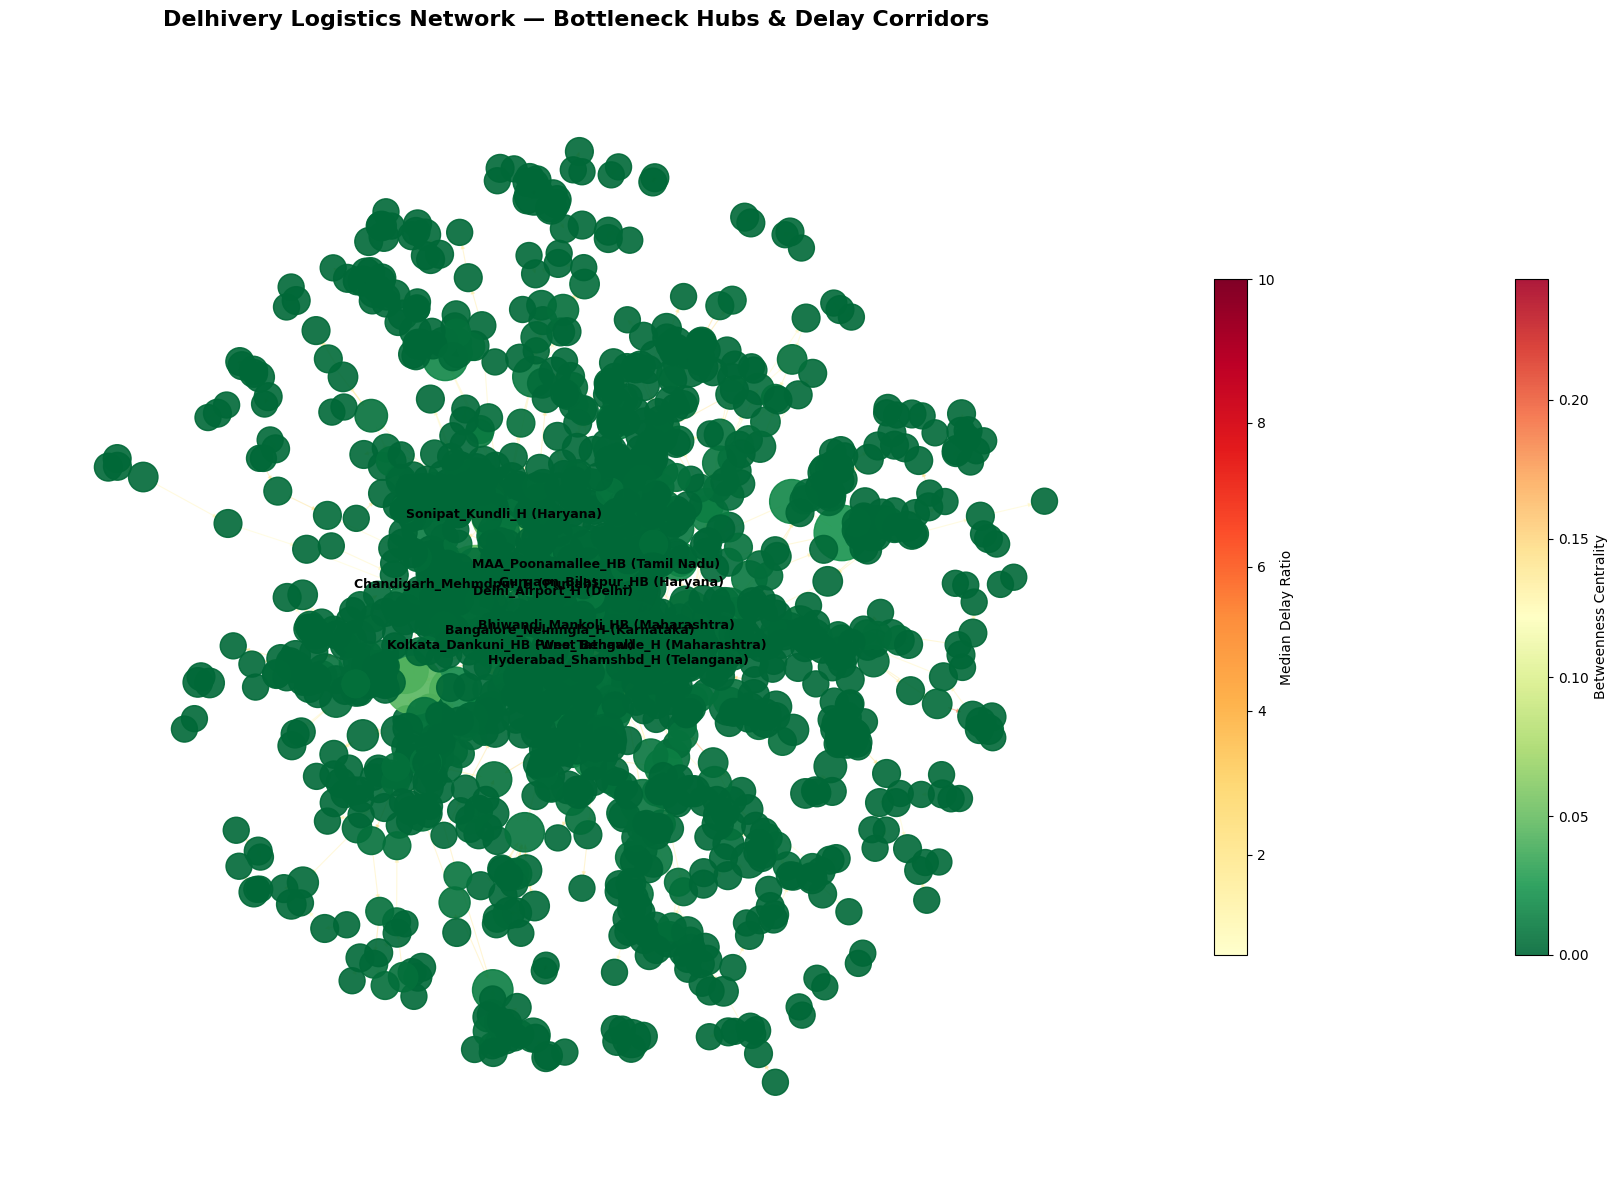

Saved: outputs/network_static.png


In [10]:
pos         = nx.spring_layout(G, seed=42, k=2)
node_sizes  = [300+(in_deg[n]+out_deg[n])*50 for n in G.nodes()]
node_colors = [betweenness[n] for n in G.nodes()]
edge_colors = [G[u][v]['weight'] for u,v in G.edges()]

fig, ax = plt.subplots(figsize=(18,12))
nx.draw_networkx_edges(G,pos,edge_color=edge_colors,edge_cmap=plt.cm.YlOrRd,
    alpha=0.4,width=0.8,arrows=True,arrowsize=6,ax=ax)
nodes = nx.draw_networkx_nodes(G,pos,node_size=node_sizes,
    node_color=node_colors,cmap=plt.cm.RdYlGn_r,alpha=0.9,ax=ax)
top10_ids = hub_df.head(10)['hub_id'].tolist()
labels    = {n: G.nodes[n].get('name',n) for n in G.nodes() if n in top10_ids}
nx.draw_networkx_labels(G,pos,labels=labels,font_size=9,font_weight='bold',ax=ax)
plt.colorbar(nodes,ax=ax,label='Betweenness Centrality',shrink=0.6)
sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd,
     norm=plt.Normalize(vmin=min(edge_colors),vmax=max(edge_colors)))
plt.colorbar(sm,ax=ax,label='Median Delay Ratio',shrink=0.6)
ax.set_title('Delhivery Logistics Network — Bottleneck Hubs & Delay Corridors',
             fontsize=16,fontweight='bold',pad=20)
ax.axis('off')
plt.tight_layout()
plt.savefig('outputs/network_static.png',dpi=150,bbox_inches='tight')
plt.show()
print('Saved: outputs/network_static.png')

## 10. Interactive pyvis Network

In [11]:
try:
    from pyvis.network import Network
    net = Network(height='700px',width='100%',directed=True,notebook=True,
                  bgcolor='#1a1a2e',font_color='white')
    risk_lookup = dict(zip(hub_df['hub_id'], hub_df['risk_score']))
    for node in G.nodes():
        score    = risk_lookup.get(node, 0)
        hub_name = G.nodes[node].get('name', str(node))
        b_val    = betweenness.get(node, 0)
        br_row   = hub_df[hub_df['hub_id']==node]['avg_breach_rate']
        br       = float(br_row.values[0]) if len(br_row)>0 else 0
        tooltip  = f'Hub: {hub_name}\nBetweenness: {b_val:.4f}\nBreach Rate: {br:.1%}\nRisk: {score:.4f}'
        if score > 0.3:   color,size = '#E24B4A',35
        elif score > 0.15:color,size = '#EF9F27',22
        elif score > 0.05:color,size = '#1D9E75',14
        else:             color,size = '#4a4a6a',8
        net.add_node(node,label=hub_name,color=color,size=size,title=tooltip)
    for u,v,d in G.edges(data=True):
        delay = d.get('weight',1)
        ec = '#E24B4A' if delay>1.5 else '#EF9F27' if delay>1.2 else '#4a4a6a'
        tip = f'Delay: {delay:.2f}x\nBreach: {d.get("breach_rate",0):.1%}\nTrips: {int(d.get("trip_count",0))}'
        net.add_edge(u,v,color=ec,width=min(delay,3),title=tip)
    net.set_options('{"physics":{"forceAtlas2Based":{"gravitationalConstant":-50,"centralGravity":0.01},"solver":"forceAtlas2Based"}}')
    net.write_html('outputs/bottleneck_network.html')
    print('Interactive network saved: outputs/bottleneck_network.html')
except ImportError:
    print('pyvis not installed. Run: pip install pyvis')

pyvis not installed. Run: pip install pyvis


## 11. Save All Outputs

In [12]:
with open('outputs/graph.pkl','wb') as f: pickle.dump(G,f)
df_clean.to_csv('outputs/processed_df.csv',index=False)
hub_df.to_csv('outputs/hub_metrics.csv',index=False)
delay_df.to_csv('outputs/delay_corridors.csv',index=False)
edge_stats_dedup.to_csv('outputs/edge_stats.csv',index=False)

print('All outputs saved:')
for fname in os.listdir('outputs'):
    size = os.path.getsize(f'outputs/{fname}')
    print(f'  {fname:45s} {size/1024:.1f} KB')

All outputs saved:
  edge_stats.csv                                194.3 KB
  eda_correlation.png                           240.9 KB
  eda_hourly.png                                88.0 KB
  eda_top_hubs.png                              119.8 KB
  graph.pkl                                     378.9 KB
  processed_df.csv                              40923.9 KB
  eda_delay_distribution.png                    58.3 KB
  delay_corridors.csv                           301.7 KB
  eda_cutoff.png                                43.7 KB
  network_static.png                            717.1 KB
  eda_route_type.png                            44.3 KB
  hub_metrics.csv                               155.9 KB
